# Session 9, Notebook 1: The Cake-Eating HJB Equation, Forward and Inverse

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 15:10-16:00, Physics-informed neural networks: applications and hands-on
**Slides:** `09_PINNs_Applications.pdf`
**Notebook role:** in-class walkthrough
**Author:** Simon Scheidegger (HEC, University of Lausanne)

The first economic application. An agent holds wealth $a$ that earns interest $r$ and chooses
consumption to maximise discounted utility; in continuous time the optimality condition is a
Hamilton-Jacobi-Bellman (HJB) equation for the value function $V(a)$, here an ordinary
differential equation, with a closed-form solution to check against. The Deep Equilibrium Net of
Day 1 enforced an Euler equation; the PINN enforces the HJB. Same idea, different operator.

Two problems on the same equation. The **forward** problem takes the parameters as given and
solves for $V$. The **inverse** problem observes consumption at a few wealth levels and recovers
the discount rate $\rho$ together with $V$, in one optimisation.

| Section | Content |
|:--|:--|
| 1 | Model, HJB, closed form |
| 2 | A trial solution with exact endpoint values, and the residual |
| 3 | Forward problem: Adam, then L-BFGS; error against the closed form |
| 4 | Inverse problem: recover $\rho$ from consumption data |

In [1]:
SEED = 42

In [2]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED); np.random.seed(SEED)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_SOFT, C_HARD = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = True   # the stored run writes the figures the slides use
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")


## 1. Model, HJB, closed form

$$\max_{c(t)} \int_0^\infty e^{-\rho t}\,\frac{c^{1-\gamma}}{1-\gamma}\,dt
  \qquad \text{s.t.} \quad \dot a = r a - c .$$

The stationary HJB equation and its first-order condition:

$$\rho V(a) = \max_c \Bigl\{ \frac{c^{1-\gamma}}{1-\gamma} + V'(a)\,(ra - c) \Bigr\},
  \qquad c^{-\gamma} = V'(a) \;\Rightarrow\; c^\star = V'(a)^{-1/\gamma}.$$

With $\kappa = \bigl(\rho - (1-\gamma)r\bigr)/\gamma$ the solution is
$V^\star(a) = \dfrac{\kappa^{-\gamma}}{1-\gamma}\,a^{1-\gamma}$ and $c^\star(a) = \kappa a$.
Parameters $\gamma = 2$, $\rho = 0.05$, $r = 0.03$ give $\kappa = 0.04$, so
$V^\star(a) = -625/a$ and the agent consumes 4 % of wealth. Since $r < \rho$, wealth falls over
time: $\dot a = (r - \kappa)\,a = -0.01\,a$.

In [3]:
gamma, rho, r = 2.0, 0.05, 0.03
kappa = (rho - (1.0 - gamma) * r) / gamma
a_min, a_max = 0.5, 5.0

V_star = lambda a: kappa**(-gamma) / (1.0 - gamma) * a**(1.0 - gamma)
c_star = lambda a: kappa * a
print(f"kappa = {kappa:.3f};  V*(a_min) = {V_star(a_min):.1f}, V*(a_max) = {V_star(a_max):.1f};  c* from {c_star(a_min):.3f} to {c_star(a_max):.3f}")

kappa = 0.040;  V*(a_min) = -1250.0, V*(a_max) = -125.0;  c* from 0.020 to 0.200


## 2. Trial solution and residual

The HJB is first order, so one boundary value pins the solution. Wealth flows towards $a_{\min}$,
which is where the value must be anchored; the trial solution fixes both endpoint values to the
closed form and lets the network shape the interior:

$$\hat V(a) = V^\star(a_{\min}) + x\,\bigl[V^\star(a_{\max}) - V^\star(a_{\min})\bigr]
  + x(1-x)\,S\,f_\theta(2x - 1), \qquad x = \frac{a - a_{\min}}{a_{\max} - a_{\min}},$$

with $S = |V^\star(a_{\min})|$ so that the network works in units of order one. The residual
substitutes the first-order condition into the HJB,

$$\mathcal{R}(a) = \rho \hat V - \Bigl[\frac{\hat c^{\,1-\gamma}}{1-\gamma} + \hat V'\,(ra - \hat c)\Bigr],
  \qquad \hat c = \hat V'^{\,-1/\gamma}.$$

Early in training $\hat V'$ can be negative, and $\hat V'^{-1/\gamma}$ is then undefined. A
`softplus` keeps it positive without killing the gradient.

In [4]:
class TrialValue(nn.Module):
    def __init__(self, width=64, depth=3):
        super().__init__()
        layers, d_in = [], 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]; d_in = width
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self.V_lo, self.V_hi, self.S = V_star(a_min), V_star(a_max), abs(V_star(a_min))
    def forward(self, a):
        x = (a - a_min) / (a_max - a_min)
        return self.V_lo + x * (self.V_hi - self.V_lo) + x * (1.0 - x) * self.S * self.net(2.0 * x - 1.0)

def consumption_and_residual(V_of, a, rho_val=rho):
    a = a.clone().requires_grad_(True)
    V = V_of(a)
    V_a = torch.autograd.grad(V, a, grad_outputs=torch.ones_like(V), create_graph=True)[0]
    V_a = nn.functional.softplus(V_a) + 1e-8
    c = V_a ** (-1.0 / gamma)
    R = rho_val * V - (c ** (1.0 - gamma) / (1.0 - gamma) + V_a * (r * a - c))
    return c, R

model = TrialValue()
a_ends = torch.tensor([[a_min], [a_max]])
print("endpoint values by construction:", model(a_ends).detach().ravel().tolist(), " closed form:", [V_star(a_min), V_star(a_max)])
print(f"trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

endpoint values by construction: [-1250.0, -125.0]  closed form: [-1250.0, -125.0]
trainable parameters: 8,513


## 3. Forward problem

Adam on 512 freshly drawn wealth levels per step, then L-BFGS on 300 fixed points in double
precision. The residual is of the order of $\rho V \sim 10$ at the start, which is why the Adam loss
starts in the thousands.

In [5]:
adam_steps, batch, lbfgs_points, lbfgs_iters = 2000, 512, 300, 300
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[800, 1500], gamma=0.4)
loss_history = []
t0 = time.time()
for step in range(1, adam_steps + 1):
    a_int = torch.rand(batch, 1) * (a_max - a_min) + a_min
    _, R = consumption_and_residual(model, a_int)
    loss = torch.mean(R ** 2)
    optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 50.0)
    optimizer.step(); scheduler.step(); loss_history.append(loss.item())
    if step % 500 == 0 or step == 1:
        print(f"Adam {step:5d}  HJB loss {loss.item():.3e}")
print(f"Adam stage: {time.time() - t0:.0f} s")

a_fixed = torch.linspace(a_min, a_max, lbfgs_points).reshape(-1, 1)
lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_iters, history_size=50,
                          tolerance_grad=1e-12, tolerance_change=1e-14, line_search_fn="strong_wolfe")
n_eval = [0]
def closure():
    lbfgs.zero_grad(); _, R = consumption_and_residual(model, a_fixed); loss = torch.mean(R ** 2); loss.backward(); n_eval[0] += 1
    if n_eval[0] % 100 == 0:
        print(f"L-BFGS eval {n_eval[0]:4d}  HJB loss {loss.item():.3e}")
    return loss
t0 = time.time(); lbfgs.step(closure)
_, R_fixed = consumption_and_residual(model, a_fixed)
print(f"L-BFGS stage: {n_eval[0]} evaluations, {time.time() - t0:.0f} s, final HJB loss {torch.mean(R_fixed ** 2).item():.3e}")

Adam     1  HJB loss 6.428e+02


Adam   500  HJB loss 7.802e-02


Adam  1000  HJB loss 1.760e-02


Adam  1500  HJB loss 1.181e-02


Adam  2000  HJB loss 5.691e-03
Adam stage: 7 s


L-BFGS eval  100  HJB loss 4.827e-05


L-BFGS eval  200  HJB loss 3.180e-05


L-BFGS eval  300  HJB loss 1.737e-05


L-BFGS stage: 360 evaluations, 2 s, final HJB loss 1.157e-05


### Error against the closed form

Three numbers for consumption: the largest absolute error, the largest relative error over the
domain, and the relative $L^2$ error. The relative error is the one to watch, since consumption
is ten times smaller at $a_{\min}$ than at $a_{\max}$.

value function:  max |V_hat - V*| / |V*| = 1.42e-04
consumption:     max |c_hat - c*| = 8.66e-04,  max relative error = 4.33e-03,  relative L2 error = 1.10e-03
HJB residual on the evaluation grid: max |R| = 1.52e-02 (compare rho V ~ 16)


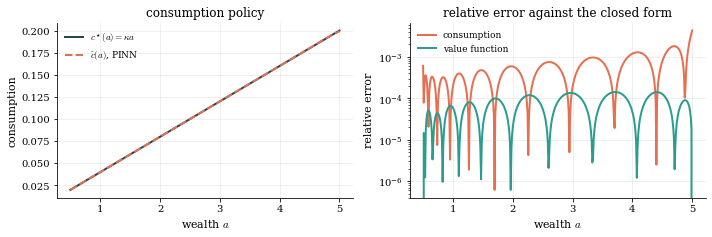

In [6]:
a_eval = torch.linspace(a_min, a_max, 400).reshape(-1, 1)
c_hat, R_eval = consumption_and_residual(model, a_eval)
with torch.no_grad():
    V_hat = model(a_eval).numpy().ravel()
a_np = a_eval.numpy().ravel(); c_hat = c_hat.detach().numpy().ravel(); R_np = R_eval.detach().numpy().ravel()
V_ex, c_ex = V_star(a_np), c_star(a_np)
rel_c = np.abs(c_hat - c_ex) / c_ex
print(f"value function:  max |V_hat - V*| / |V*| = {np.max(np.abs(V_hat - V_ex) / np.abs(V_ex)):.2e}")
print(f"consumption:     max |c_hat - c*| = {np.abs(c_hat - c_ex).max():.2e},  max relative error = {rel_c.max():.2e},  relative L2 error = {np.sqrt(np.mean((c_hat - c_ex)**2) / np.mean(c_ex**2)):.2e}")
print(f"HJB residual on the evaluation grid: max |R| = {np.abs(R_np).max():.2e} (compare rho V ~ {abs(rho * V_ex).mean():.0f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(a_np, c_ex, color=C_TRUE, lw=2, label=r"$c^\star(a) = \kappa a$")
axes[0].plot(a_np, c_hat, "--", color=C_SOFT, lw=2, label=r"$\hat c(a)$, PINN")
axes[0].set_xlabel("wealth $a$"); axes[0].set_ylabel("consumption"); axes[0].legend(frameon=False); axes[0].set_title("consumption policy")
axes[1].semilogy(a_np, rel_c, color=C_SOFT, lw=2, label="consumption")
axes[1].semilogy(a_np, np.abs(V_hat - V_ex) / np.abs(V_ex), color=C_HARD, lw=2, label="value function")
axes[1].set_xlabel("wealth $a$"); axes[1].set_ylabel("relative error"); axes[1].legend(frameon=False); axes[1].set_title("relative error against the closed form")
fig.tight_layout(); savefig(fig, "pinn_cake_eating"); plt.show()

## 4. Inverse problem: recover $\rho$ from consumption data

Suppose $\rho$ is unknown and consumption is observed at 20 wealth levels, with 1 % measurement
noise. The discount rate becomes one more trainable parameter, $\log\rho$, and the loss gains a
data term:

$$\mathcal{L}(\theta, \rho) = \frac{1}{N}\sum_i \Bigl(\frac{\mathcal{R}(a_i;\theta,\rho)}{\rho_0 S}\Bigr)^2
  + \frac{1}{20}\sum_{k=1}^{20} \Bigl(\frac{\hat c(a_k) - c^{\text{obs}}_k}{c^{\text{obs}}_k}\Bigr)^2 .$$

The data replace the boundary conditions: the network for $V$ is now free, $\hat V = S\,f_\theta$,
because the consumption observations pin $V'$ over the domain and the HJB then pins $\rho$ and the
level of $V$. Same optimiser, same loop, one extra tensor. Start at $\rho_0 = 0.08$.

noise   0%:  rho_hat = 0.05001  (true 0.05, start 0.08),  final loss 4.98e-08,  17 s


noise   1%:  rho_hat = 0.04945  (true 0.05, start 0.08),  final loss 8.39e-05,  17 s


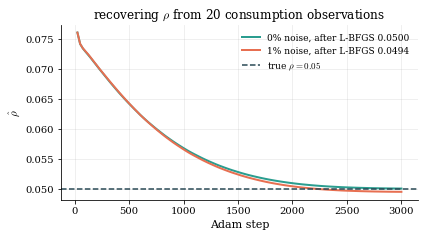

In [7]:
class FreeValue(nn.Module):
    def __init__(self, width=64, depth=3):
        super().__init__()
        layers, d_in = [], 1
        for _ in range(depth):
            layers += [nn.Linear(d_in, width), nn.Tanh()]; d_in = width
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers); self.S = abs(V_star(a_min))
    def forward(self, a):
        return self.S * self.net(2.0 * (a - a_min) / (a_max - a_min) - 1.0)

rho_0, S_V = 0.08, abs(V_star(a_min))
a_obs = torch.linspace(a_min, a_max, 20).reshape(-1, 1)

def solve_inverse(noise, seed=1, adam_steps=3000, lbfgs_iters=500):
    torch.manual_seed(seed)
    c_obs = c_star(a_obs) * (1.0 + noise * torch.randn_like(a_obs))
    net = FreeValue(); log_rho = torch.tensor(np.log(rho_0), requires_grad=True)
    params = list(net.parameters()) + [log_rho]
    def loss_fn(a_int):
        rho_hat = torch.exp(log_rho)
        _, R = consumption_and_residual(net, a_int, rho_hat)
        c_fit, _ = consumption_and_residual(net, a_obs, rho_hat)
        return torch.mean((R / (rho_0 * S_V)) ** 2) + torch.mean(((c_fit - c_obs) / c_obs) ** 2)
    opt = torch.optim.Adam(params, lr=2e-3); path = []
    for step in range(1, adam_steps + 1):
        loss = loss_fn(torch.rand(512, 1) * (a_max - a_min) + a_min)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 25 == 0:
            path.append((step, torch.exp(log_rho).item()))
    a_fix = torch.linspace(a_min, a_max, 300).reshape(-1, 1)
    lb = torch.optim.LBFGS(params, max_iter=lbfgs_iters, history_size=50, tolerance_grad=1e-12, tolerance_change=1e-14, line_search_fn="strong_wolfe")
    def closure():
        lb.zero_grad(); l = loss_fn(a_fix); l.backward(); return l
    lb.step(closure)
    return torch.exp(log_rho).item(), loss_fn(a_fix).item(), np.array(path)

results = {}
for noise in [0.0, 0.01]:
    t0 = time.time()
    rho_hat, final, path = solve_inverse(noise)
    results[noise] = (rho_hat, path)
    print(f"noise {noise:4.0%}:  rho_hat = {rho_hat:.5f}  (true 0.05, start {rho_0}),  final loss {final:.2e},  {time.time() - t0:.0f} s")

fig, ax = plt.subplots(figsize=(6, 3.4))
for (noise, (rho_hat, path)), col in zip(results.items(), [C_HARD, C_SOFT]):
    ax.plot(path[:, 0], path[:, 1], color=col, lw=2, label=f"{noise:.0%} noise, after L-BFGS {rho_hat:.4f}")
ax.axhline(rho, color=C_TRUE, ls="--", lw=1.5, label=r"true $\rho = 0.05$")
ax.set_xlabel("Adam step"); ax.set_ylabel(r"$\hat\rho$"); ax.legend(frameon=False); ax.set_title(r"recovering $\rho$ from 20 consumption observations")
fig.tight_layout(); savefig(fig, "pinn_cake_inverse"); plt.show()

## Summary

* **Forward.** The trial solution makes the endpoint values exact and leaves the interior to the
  HJB residual. After Adam and L-BFGS the consumption policy is within $4.3\times10^{-3}$ of
  $\kappa a$ everywhere (relative $L^2$ error $1.1\times10^{-3}$), and the value function within
  $1.4\times10^{-4}$. The HJB residual is $10^{-2}$ against $\rho V \sim 16$.
* **Inverse.** With $\rho$ unknown and consumption observed at 20 wealth levels, the same loop
  recovers $\rho = 0.0500$ from a start at $0.08$; with 1 % noise on the observations it
  returns $0.0495$. Estimation and solution in one optimisation, one extra tensor.
* **What made it work.** The endpoint values pin the solution of a first-order equation, and the
  data do the same job in the inverse problem. Notebook `09_03` shows what happens when neither
  is available.